# Семинар 1. Линейная регрессия

#### Шаг 1. Загрузка датасета и вывод на экран

In [17]:
# Ваш код
from pathlib import Path
import pandas as pd

dataset_path = Path("delivery_dataset.csv")
if not dataset_path.exists():
    dataset_path = Path("LABS/#1/delivery_dataset.csv")

df = pd.read_csv(dataset_path)
df.head()

,Дата заказа (ГГГГ-ММ-ДД),Шифр заказа (ID),Расстояние до клиента (в км),Количество позиций в чеке (в шт.),Балл пробок на дорогах (в баллах),Погода (в градусах Цельсия),Этаж доставки (в этажах),Время доставки (в минутах)
0,2026-09-08,ORD-202608001,11.3,1,9,21.0,6,79.2
1,2026-08-29,ORD-202608002,7.3,3,7,27.0,7,46.6
2,2026-08-15,ORD-202608003,2.2,1,3,20.0,5,16.3
3,2026-08-08,ORD-202608004,0.9,2,6,22.9,1,15.8
4,2026-08-21,ORD-202608005,12.3,14,4,18.1,2,69.2


#### Шаг2. Разделение выборки на тренировочную, валидационную и тестовую с выбором нужных столбцов:
* в тренировочной: 300 первых заказов;
* в валидационной: 100 следующих; 
* в тестовой: 100 последних.

In [18]:
# Ваш код
base_feature_columns = [
    "Расстояние до клиента (в км)",
    "Количество позиций в чеке (в шт.)",
    "Балл пробок на дорогах (в баллах)",
    "Погода (в градусах Цельсия)",
    "Этаж доставки (в этажах)",
]
target_column = "Время доставки (в минутах)"

X = df[base_feature_columns].copy()

# Учитываем совместное влияние расстояния и пробок.
X["Расстояние × пробки"] = (
    X["Расстояние до клиента (в км)"]
    * X["Балл пробок на дорогах (в баллах)"]
)
feature_columns = X.columns.tolist()
y = df[target_column]

X_train, y_train = X.iloc[:300], y.iloc[:300]
X_val, y_val = X.iloc[300:400], y.iloc[300:400]
X_test, y_test = X.iloc[400:], y.iloc[400:]

#### Вопрос 1. 

Для чего мы разбиваем данные на выборки? Для чего нам нужна тренировачная, для чего валидационная, для чего тестовая?

Тренировочные нужны для того, чтобы на них обучалась модель и подбирала оптимальные весовые значения, валидационные же для проверки обученной модели и подбора настраиваемых параметров, которые не обучаются. Тестовые же данные нужны для проверки готовой модели, данные в тестах не используется в обучении 

#### Шаг 3. Установка sklearn чтобы обучать модель линейной регрессии через Ridge

In [19]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


#### Шаг 4. Обучение модели линейной регрессии на тренировочной выборке с помощью Ridge и sparse_cg

In [20]:
import numpy as np
from IPython.display import display
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

# Средние и масштабы определяем только на train.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

ridge_alpha = 10.0
ridge_model = Ridge(
    alpha=ridge_alpha,
    solver="sparse_cg",
    max_iter=1000,
    tol=1e-6,
)
ridge_model.fit(X_train_scaled, y_train)


Ridge(alpha=10.0, max_iter=1000, solver='sparse_cg', tol=1e-06)

#### Шаг 5. Вывод на экран графиков ошибок (SSE, MSE, RMSE) в зависимости от итераций для train и val выборок.

Остановка на итерации 7: норма невязки меньше epsilon.


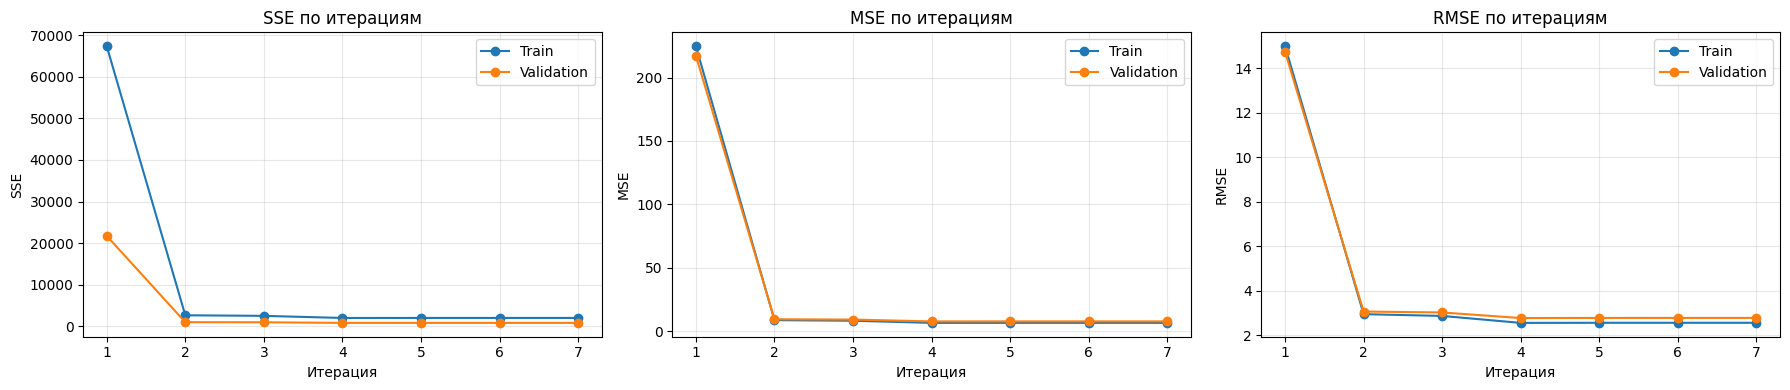

Train RMSE: 2.555
Validation RMSE: 2.773


In [21]:
# Ваш код
import numpy as np
import matplotlib.pyplot as plt

X_train_cg = np.column_stack((np.ones(len(X_train)), X_train_scaled))
X_val_cg = np.column_stack((np.ones(len(X_val)), X_val_scaled))
y_train_array = y_train.to_numpy()
y_val_array = y_val.to_numpy()

def calculate_metrics(y_true, y_pred):
    errors = y_true - y_pred
    sse = np.sum(errors ** 2)
    mse = np.mean(errors ** 2)
    rmse = np.sqrt(mse)
    return sse, mse, rmse

A = X_train_cg.T @ X_train_cg
A[1:, 1:] += ridge_alpha * np.eye(A.shape[0] - 1)
b = X_train_cg.T @ y_train_array

weights = np.zeros(X_train_cg.shape[1])
residual = b - A @ weights
direction = residual.copy()

epsilon = 1e-8
max_iterations = 10
history = {
    "train_sse": [], "val_sse": [],
    "train_mse": [], "val_mse": [],
    "train_rmse": [], "val_rmse": [],
}

for iteration in range(1, max_iterations + 1):
    residual_squared = residual @ residual
    A_direction = A @ direction
    step_size = residual_squared / (direction @ A_direction)

    weights = weights + step_size * direction
    next_residual = residual - step_size * A_direction

    train_prediction = X_train_cg @ weights
    val_prediction = X_val_cg @ weights
    for split, y_true, y_pred in [
        ("train", y_train_array, train_prediction),
        ("val", y_val_array, val_prediction),
    ]:
        sse, mse, rmse = calculate_metrics(y_true, y_pred)
        history[f"{split}_sse"].append(sse)
        history[f"{split}_mse"].append(mse)
        history[f"{split}_rmse"].append(rmse)

    if np.linalg.norm(next_residual) < epsilon:
        print(f"Остановка на итерации {iteration}: норма невязки меньше epsilon.")
        break

    beta = (next_residual @ next_residual) / residual_squared
    direction = next_residual + beta * direction
    residual = next_residual
else:
    print("Остановка: достигнуто максимальное число итераций.")

iterations = range(1, len(history["train_sse"]) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, metric, title in zip(axes, ["sse", "mse", "rmse"], ["SSE", "MSE", "RMSE"]):
    ax.plot(iterations, history[f"train_{metric}"], marker="o", label="Train")
    ax.plot(iterations, history[f"val_{metric}"], marker="o", label="Validation")
    ax.set_title(f"{title} по итерациям")
    ax.set_xlabel("Итерация")
    ax.set_ylabel(title)
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

print(f"Train RMSE: {history['train_rmse'][-1]:.3f}")
print(f"Validation RMSE: {history['val_rmse'][-1]:.3f}")

#### Вопрос 2.

Какую информацию про нашу модель несут эти графики?

Графики показывают как будет меняться ошибка с каждой итерацией, то есть с новыми параметрами, можно отслеживать скорость сходимости, и смотреть естььь ли преобучение.


SSE - сумма квадратичных отклонений
MSE - средеее квадратичная ошибка
RMSE - Корень из средней квадратичной ошибки, хороша тем, что она показывает ошибку в тех же единицах измерения, что и таргет


#### Вопрос 3. 

Какая траектория линий train и val ошибок будет на графиках недообученной модели и почему?

Какая траектория линий train и val ошибок будет на графиках обученной модели и почему?

Какая траектория линий train и val ошибок будет на графиках переобученной модели и почему?

1 - При недообучении ошибки на train и validation остаются высокими, то есть модель слишком простая, регуляризация слишком сильная или обучение остановлено слишком рано.
2 - Если на трейн и вал ошибки уменьшаются, то модель обучилась норм, то есть и на новых данных, на которых модель не обучалась ошибка тоже уменьшается
3 - Если на графиках трейна ошибки падают, а на вал растут, то это признак переобучения, потому что при обучении модель подстроилась под тренировчные данные и концентрируется на определнных данных 

#### Шаг 6. Применение модели на тестовой выборке

In [22]:
# Ваш код
# Применяем обученный scaler без повторного fit.
X_test_scaled = scaler.transform(X_test)
y_predict_ridge = ridge_model.predict(X_test_scaled)

X_test_cg = np.column_stack((np.ones(len(X_test)), X_test_scaled))
y_predict_manual = X_test_cg @ weights

y_test_array = y_test.to_numpy()
ridge_sse = np.sum((y_test_array - y_predict_ridge) ** 2)
manual_sse = np.sum((y_test_array - y_predict_manual) ** 2)

print(f"SSE модели Ridge.fit(): {ridge_sse:.4f}")
print(f"SSE ручного метода сопряжённых градиентов: {manual_sse:.4f}")

y_predict = y_predict_ridge
test_results = pd.DataFrame({
    "ID заказа": df.loc[X_test.index, "Шифр заказа (ID)"].to_numpy(),
    "Прогноз времени доставки": y_predict,
    "Фактическое время доставки": y_test_array,
    "Разница (факт - прогноз)": y_test_array - y_predict,
})

display(test_results.round(3))

output_path = dataset_path.parent / "test_predictions_improved.csv"
test_results.to_csv(output_path, index=False)

SSE модели Ridge.fit(): 563.8110
SSE ручного метода сопряжённых градиентов: 563.8110


,ID заказа,Прогноз времени доставки,Фактическое время доставки,Разница (факт - прогноз)
0,ORD-202608401,30.224,33.9,3.676
1,ORD-202608402,34.486,33.1,-1.386
2,ORD-202608403,16.608,16.3,-0.308
3,ORD-202608404,34.877,34.7,-0.177
4,ORD-202608405,16.552,13.3,-3.252
...,...,...,...,...
95,ORD-202608496,31.424,28.9,-2.524
96,ORD-202608497,54.414,48.0,-6.414
97,ORD-202608498,29.765,27.0,-2.765
98,ORD-202608499,41.570,40.4,-1.170


#### Шаг 7. RMSE на тестовой выборке

In [23]:
# Ваш код
ridge_rmse = np.sqrt(np.mean((y_test_array - y_predict_ridge) ** 2))
manual_rmse = np.sqrt(np.mean((y_test_array - y_predict_manual) ** 2))

print(f"Test RMSE модели Ridge: {ridge_rmse:.3f} минут")
print(f"Test RMSE ручного метода: {manual_rmse:.3f} минут")

Test RMSE модели Ridge: 2.374 минут
Test RMSE ручного метода: 2.374 минут


#### Вопрос 4.

Что получившийся RMSE может сказать о нашей модели?

На тестовых данных RMSE получилась 2,374 минуты. Эта метрика оценивает ошибку прогноза, причём большие отклонения влияют на неё сильнее, чем небольшие. Это не средняя абсолютная ошибка и не предел ошибки отдельного заказа. Просто метрика, которая показывает ошибку при предсказании с учетом чувстивтельности сильных перепрогнозов или же наоборот недопрогноза